# 03 Generativna klasifikacija

Ovaj notebook je fokusiran samo na generativnu klasifikaciju Turismy recenzija i njeno poredjenje sa najboljim klasicnim klasifikacionim modelom.

Prikazuje:

- kako je postavljen generativni klasifikator kroz label-by-label promptove
- koje metrike daje generativni model za sve cetiri oznake
- ukupno i per-label poredjenje sa klasicnim TF-IDF klasifikatorom
- primere sirovih generativnih odgovora i parsiranih 0/1 oznaka

Notebook cita vec generisane metrike iz artifacts/metrics/, pa se brzo otvara bez ponovnog lokalnog inference-a.


In [21]:
from pathlib import Path
import sys

_PROJECT_MARKERS = (
    Path('src') / 'data' / 'prepare_dataset.py',
    Path('Turismy') / 'reviews.csv',
)


def _is_project_root(path):
    return all((path / marker).exists() for marker in _PROJECT_MARKERS)


def _candidate_roots(start):
    start = start.resolve()
    seen = set()

    for candidate in (start, *start.parents):
        if candidate not in seen:
            seen.add(candidate)
            yield candidate

    for base in (start, start.parent):
        try:
            children = list(base.iterdir())
        except OSError:
            continue

        for child in children:
            try:
                if not child.is_dir():
                    continue
                candidate = child.resolve()
            except OSError:
                continue

            if candidate not in seen:
                seen.add(candidate)
                yield candidate


def find_project_root():
    for candidate in _candidate_roots(Path.cwd()):
        if _is_project_root(candidate):
            return candidate

    raise RuntimeError('Project root was not found.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/mina/git_repos/MasinskoUcenje-Projekat')

In [22]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.models.evaluate import LABEL_COLUMNS
from src.models.prompt_classification import DEFAULT_MODEL_NAME, build_label_prompt, parse_binary_answer

sns.set_theme(style='whitegrid')

metrics_dir = PROJECT_ROOT / 'artifacts' / 'metrics'


def load_json(name):
    path = metrics_dir / name
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run the optional rerun cell at the end of this notebook '
            'or run: .venv311/bin/python -m src.models.prompt_classification --sample-size 500'
        )
    return json.loads(path.read_text(encoding='utf-8'))


classification_metrics = load_json('classification_metrics.json')
prompt_metrics = load_json('prompt_metrics.json')

loaded = pd.DataFrame(
    [
        {'artifact': 'classification_metrics.json', 'purpose': 'Klasicni TF-IDF klasifikatori'},
        {'artifact': 'prompt_metrics.json', 'purpose': 'Generativna klasifikacija kroz promptove'},
    ]
)
display(loaded)


,artifact,purpose
0,classification_metrics.json,Klasicni TF-IDF klasifikatori
1,prompt_metrics.json,Generativna klasifikacija kroz promptove


## Model i postupak generativne klasifikacije

Generativni model se ne trenira nad ovim skupom, vec se koristi kao lokalni instruction model koji za svaku recenziju odgovara na cetiri binarna pitanja. Svaka labela dobija poseban prompt, model vraca yes ili no, a odgovor se zatim parsira u 1 ili 0.

U projektu ostaje Qwen/Qwen3-4B-Instruct-2507 zato sto je praktican izbor za lokalni transformers tok: dovoljno je jak za instruction promptove, nije gated na Hugging Face-u i ne uvodi posebne GGUF/MLX alate. Veci ili kvantizovani modeli mogu biti zanimljivi za dodatni eksperiment, ali bi promenili inference stack i nisu potrebni za osnovno poredjenje.


In [23]:
model_setup = pd.DataFrame(
    [
        {'field': 'model', 'value': prompt_metrics.get('model', DEFAULT_MODEL_NAME)},
        {'field': 'labels', 'value': ', '.join(LABEL_COLUMNS)},
        {'field': 'prompting', 'value': 'one binary question per label'},
        {'field': 'raw output', 'value': 'yes/no'},
        {'field': 'parsed output', 'value': '0/1 multi-label vector'},
        {'field': 'sample_size', 'value': prompt_metrics.get('sample_size')},
    ]
)

display(Markdown('### Konfiguracija generativnog klasifikatora'))
display(model_setup)

example_comment = 'Spotless family apartment near the city center with a beautiful private terrace.'
example_prompts = pd.DataFrame(
    [
        {
            'label': label,
            'prompt': build_label_prompt(example_comment, label),
            'parse_yes': parse_binary_answer('yes'),
            'parse_no': parse_binary_answer('no'),
        }
        for label in LABEL_COLUMNS
    ]
)

display(Markdown('### Primer label-by-label prompta'))
display(example_prompts)


### Konfiguracija generativnog klasifikatora

,field,value
0,model,Qwen/Qwen3-4B-Instruct-2507
1,labels,"cleanliness, location, luxury, family_friendly"
2,prompting,one binary question per label
3,raw output,yes/no
4,parsed output,0/1 multi-label vector
5,sample_size,500


### Primer label-by-label prompta

,label,prompt,parse_yes,parse_no
0,cleanliness,Review: Spotless family apartment near the cit...,1,0
1,location,Review: Spotless family apartment near the cit...,1,0
2,luxury,Review: Spotless family apartment near the cit...,1,0
3,family_friendly,Review: Spotless family apartment near the cit...,1,0


## Metrike generativnog modela

Prvo prikazujemo odvojene metrike samo za generativni model. U istom outputu su njegove ukupne multi-label metrike (`metric_scope = overall`) i per-label metrike (`metric_scope = per_label`), bez mesanja sa klasicnim modelom.


In [ ]:
metric_columns = [
    'micro_precision',
    'micro_recall',
    'micro_f1',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'subset_accuracy',
]
per_label_metric_columns = ['precision', 'recall', 'f1', 'support']
prompt_label = 'Generativni Qwen prompt'

generative_rows = [
    {
        'metric_scope': 'overall',
        'label': 'all_labels',
        'approach': prompt_label,
        'model': prompt_metrics.get('model', DEFAULT_MODEL_NAME),
        'sample_size': prompt_metrics.get('sample_size'),
        **{column: prompt_metrics[column] for column in metric_columns},
        'precision': pd.NA,
        'recall': pd.NA,
        'f1': pd.NA,
        'support': pd.NA,
    }
]

for label, payload in prompt_metrics['per_label'].items():
    generative_rows.append(
        {
            'metric_scope': 'per_label',
            'label': label,
            'approach': prompt_label,
            'model': prompt_metrics.get('model', DEFAULT_MODEL_NAME),
            'sample_size': prompt_metrics.get('sample_size'),
            **{column: pd.NA for column in metric_columns},
            **{column: payload[column] for column in per_label_metric_columns},
        }
    )

generative_metrics_output = pd.DataFrame(generative_rows)
metric_value_columns = [*metric_columns, *per_label_metric_columns]
generative_metrics_output[metric_value_columns] = generative_metrics_output[metric_value_columns].astype('Float64').round(4)

display(generative_metrics_output)


## Uporedne metrike generativnog i klasicnog modela

Posle odvojenog prikaza generativnog modela ide zajednicki output za poredjenje sa najboljim klasicnim TF-IDF klasifikatorom. Ova tabela koristi iste ukupne i per-label metrike, uz `f1_delta_vs_classic` za razliku generativnog modela u odnosu na klasicni.


In [ ]:
best_classic_name = classification_metrics['best_model']
best_classic = classification_metrics['models'][best_classic_name]
classic_label = f'Klasicni TF-IDF ({best_classic_name})'
prompt_comparison_label = 'Generativni Qwen prompt'

summary = pd.DataFrame(
    [
        {
            'approach': classic_label,
            'model': best_classic_name,
            'sample_size': 'test split',
            **{column: best_classic[column] for column in metric_columns},
        },
        {
            'approach': prompt_comparison_label,
            'model': prompt_metrics.get('model', DEFAULT_MODEL_NAME),
            'sample_size': prompt_metrics.get('sample_size'),
            **{column: prompt_metrics[column] for column in metric_columns},
        },
    ]
)


def per_label_frame(name, payload):
    frame = pd.DataFrame(payload['per_label']).T.reset_index().rename(columns={'index': 'label'})
    frame.insert(0, 'approach', name)
    return frame


per_label = pd.concat(
    [
        per_label_frame(classic_label, best_classic),
        per_label_frame(prompt_comparison_label, prompt_metrics),
    ],
    ignore_index=True,
)

classic_overall = summary.loc[summary['approach'] == classic_label, metric_columns].iloc[0]
classic_per_label = per_label[per_label['approach'] == classic_label].set_index('label')

overall_rows = []
for row in summary.to_dict('records'):
    f1_delta = row['micro_f1'] - classic_overall['micro_f1'] if row['approach'] == prompt_comparison_label else 0.0
    overall_rows.append(
        {
            'metric_scope': 'overall',
            'label': 'all_labels',
            'approach': row['approach'],
            'model': row['model'],
            'sample_size': row['sample_size'],
            **{column: row[column] for column in metric_columns},
            'precision': pd.NA,
            'recall': pd.NA,
            'f1': pd.NA,
            'support': pd.NA,
            'f1_delta_vs_classic': f1_delta,
        }
    )

per_label_rows = []
for row in per_label.to_dict('records'):
    classic_f1 = classic_per_label.loc[row['label'], 'f1']
    f1_delta = row['f1'] - classic_f1 if row['approach'] == prompt_comparison_label else 0.0
    per_label_rows.append(
        {
            'metric_scope': 'per_label',
            'label': row['label'],
            'approach': row['approach'],
            'model': best_classic_name if row['approach'] == classic_label else prompt_metrics.get('model', DEFAULT_MODEL_NAME),
            'sample_size': 'test split' if row['approach'] == classic_label else prompt_metrics.get('sample_size'),
            **{column: pd.NA for column in metric_columns},
            'precision': row['precision'],
            'recall': row['recall'],
            'f1': row['f1'],
            'support': row['support'],
            'f1_delta_vs_classic': f1_delta,
        }
    )

comparison_metrics_output = pd.DataFrame(overall_rows + per_label_rows)
comparison_metric_value_columns = [*metric_columns, *per_label_metric_columns, 'f1_delta_vs_classic']
comparison_metrics_output[comparison_metric_value_columns] = comparison_metrics_output[comparison_metric_value_columns].astype('Float64').round(4)

display(comparison_metrics_output)


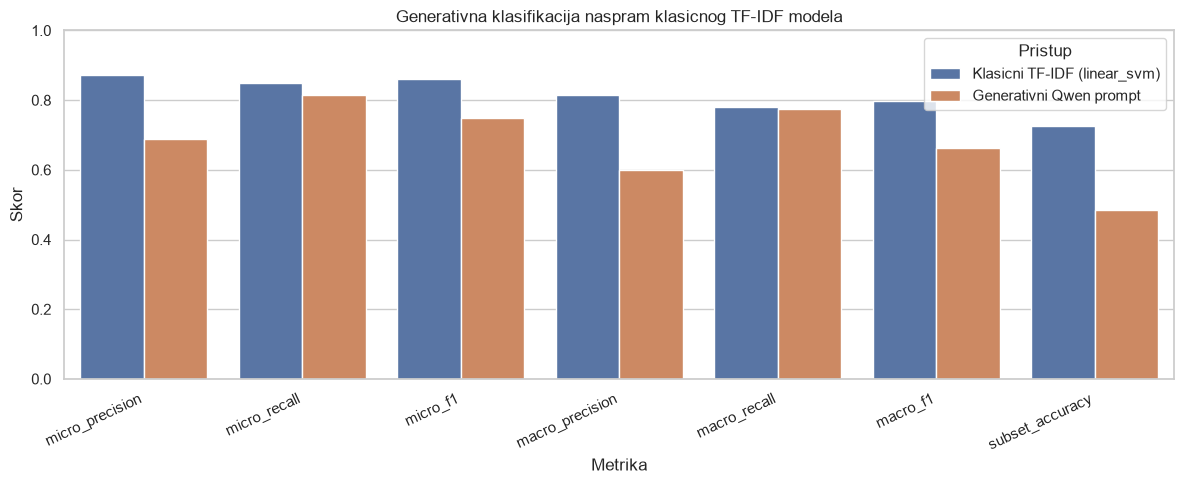

In [25]:
plot_data = summary.melt(
    id_vars=['approach'],
    value_vars=metric_columns,
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x='metric', y='score', hue='approach')
plt.ylim(0, 1)
plt.title('Generativna klasifikacija naspram klasicnog TF-IDF modela')
plt.xlabel('Metrika')
plt.ylabel('Skor')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Pristup')
plt.tight_layout()
plt.show()


## Vizuelno poredjenje po labeli

Uporedna tabela iznad je glavni metrički output za poredjenje. Grafikon ispod koristi iste `per_label` podatke samo da se lakse vidi razlika u F1 po labelama.


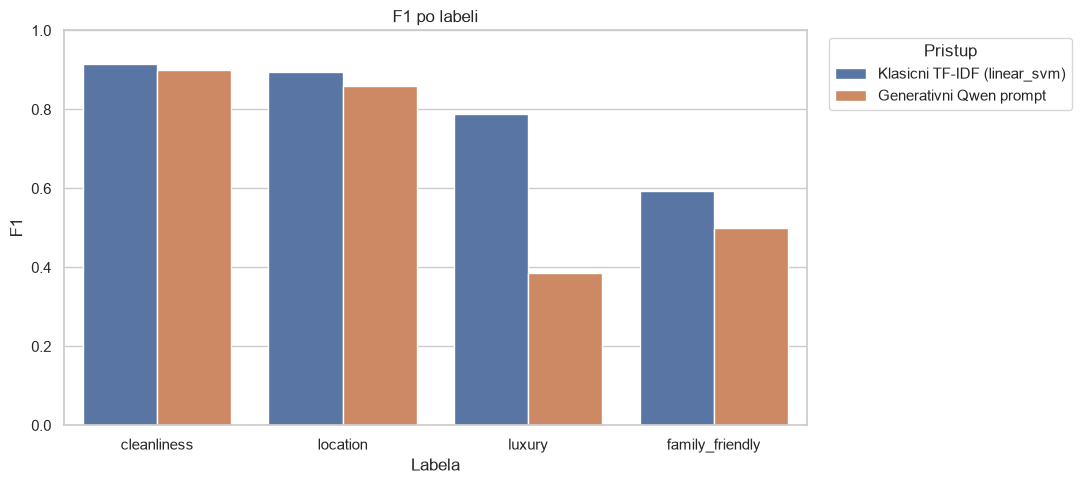

In [26]:
plt.figure(figsize=(11, 5))
sns.barplot(data=per_label, x='label', y='f1', hue='approach')
plt.ylim(0, 1)
plt.title('F1 po labeli')
plt.xlabel('Labela')
plt.ylabel('F1')
plt.legend(title='Pristup', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Primeri generativnih izlaza

Tabela ispod prikazuje stvarne komentare, sirove odgovore modela za svaku labelu i parsirane vrednosti 0/1. Ovaj deo je koristan za objasnjenje kako se tekstualni generativni izlaz pretvara u klasifikacioni rezultat.


In [27]:
prompt_examples = []
for index, example in enumerate(prompt_metrics.get('examples', [])[:8], start=1):
    raw_outputs = example.get('raw_outputs', {})
    parsed = example.get('parsed', {})
    prompt_examples.append(
        {
            'example': index,
            'comment': example['comment'][:180] + ('...' if len(example['comment']) > 180 else ''),
            'raw cleanliness': raw_outputs.get('cleanliness'),
            'raw location': raw_outputs.get('location'),
            'raw luxury': raw_outputs.get('luxury'),
            'raw family': raw_outputs.get('family_friendly'),
            'parsed cleanliness': parsed.get('cleanliness'),
            'parsed location': parsed.get('location'),
            'parsed luxury': parsed.get('luxury'),
            'parsed family': parsed.get('family_friendly'),
        }
    )

examples_frame = pd.DataFrame(prompt_examples)
if examples_frame.empty:
    display(Markdown('Nema sacuvanih primera u prompt metrikama. Pokreni opcioni rerun da se generisu.'))
else:
    display(examples_frame)


,example,comment,raw cleanliness,raw location,raw luxury,raw family,parsed cleanliness,parsed location,parsed luxury,parsed family
0,1,Fantastic weekend in Amsterdam! The boat is co...,no,yes,yes,no,0,1,1,0
1,2,The place is lovely! very unique and cozy! Sha...,no,no,yes,yes,0,0,1,1
2,3,Perfect location; quiet but lived in. Boat is ...,no,yes,no,no,0,1,0,0
3,4,"Diewert is a fine gentleman, and a very accomm...",no,no,no,no,0,0,0,0
4,5,"convenient location, easy to get everywhere an...",no,yes,no,no,0,1,0,0
5,6,This houseboat is the perfect place to stay in...,no,yes,no,no,0,1,0,0
6,7,Alex was welcoming and helpful. The room was j...,no,yes,no,no,0,1,0,0
7,8,edwin是一个非常幽默的人，同时他也很热情，很周到。提供的房间不大，但是很温馨，很好，非常喜欢,no,no,no,no,0,0,0,0


## Kratko tumacenje rezultata

Zakljucak ispod koristi uporedne metrike iz prethodnog outputa. Pozitivna razlika u `f1_delta_vs_classic` znaci da je generativni model bolji od klasicnog za taj red, a negativna da je klasicni model bolji.


In [28]:
winner = summary.loc[summary['micro_f1'].idxmax()]
strongest_prompt_label = (
    per_label[per_label['approach'] == prompt_label]
    .sort_values('f1', ascending=False)
    .iloc[0]
)
weakest_prompt_label = (
    per_label[per_label['approach'] == prompt_label]
    .sort_values('f1', ascending=True)
    .iloc[0]
)
prompt_micro_delta = (
    summary.loc[summary['approach'] == prompt_label, 'micro_f1'].iloc[0]
    - summary.loc[summary['approach'] == classic_label, 'micro_f1'].iloc[0]
)

display(
    Markdown(
        f'''### Zakljucak

- Najbolji micro F1 u ovom poredjenju: **{winner['approach']}** ({winner['micro_f1']:.4f}).
- Generativni model ima micro F1 razliku u odnosu na klasicni model: **{prompt_micro_delta:.4f}**.
- Generativni model je najjaci na labeli **{strongest_prompt_label['label']}** (F1={strongest_prompt_label['f1']:.4f}).
- Generativni model je najslabiji na labeli **{weakest_prompt_label['label']}** (F1={weakest_prompt_label['f1']:.4f}).
- Glavna prednost generativnog pristupa je sto ne zahteva treniranje za novi skup labela; glavna mana je sporiji inference i veca osetljivost na prompt.
'''
    )
)


### Zakljucak

- Najbolji micro F1 u ovom poredjenju: **Klasicni TF-IDF (linear_svm)** (0.8618).
- Generativni model ima micro F1 razliku u odnosu na klasicni model: **-0.1143**.
- Generativni model je najjaci na labeli **cleanliness** (F1=0.9011).
- Generativni model je najslabiji na labeli **luxury** (F1=0.3846).
- Glavna prednost generativnog pristupa je sto ne zahteva treniranje za novi skup labela; glavna mana je sporiji inference i veca osetljivost na prompt.


## Opcioni rerun samo za ovaj fokus

Sledeca celija nije potrebna za prezentaciju. Koristi se samo ako zelis da ponovo napravis artefakte za klasicni klasifikator i generativni prompt model. Podrazumevano je iskljucena jer generativni inference moze dugo da traje lokalno.


In [29]:
RUN_GENERATIVE_EXPERIMENT = False
PROMPT_SAMPLE_SIZE = 500

if RUN_GENERATIVE_EXPERIMENT:
    from src.data.prepare_dataset import prepare_dataset
    from src.models.prompt_classification import run_prompt_classification, save_prompt_result
    from src.models.train_classic import save_classification_result, train_classification_models

    df = prepare_dataset()

    classic_result = train_classification_models(df)
    save_classification_result(classic_result)

    prompt_result = run_prompt_classification(df, sample_size=PROMPT_SAMPLE_SIZE)
    save_prompt_result(prompt_result)

    print(
        f'Finished. Classic micro_f1={classic_result.metrics["micro_f1"]:.4f}; '
        f'generative micro_f1={prompt_result.metrics["micro_f1"]:.4f}'
    )
else:
    print('RUN_GENERATIVE_EXPERIMENT is False. Existing artifacts are displayed above.')


RUN_GENERATIVE_EXPERIMENT is False. Existing artifacts are displayed above.
